#Flujo de trabajo en un modelo de clasificación con Redes Neuronales

##1. Formular/Delinear el problema

###Set de Datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/penguins.csv")

In [ ]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


La columna 'Species' hace referencia al tipo de pinguinos que podemos clasificar en el dataset.

* bill_length_mm: largo del pico en milimetros
* bill_depth_mm: profundidad del pico en milimetros
* flipper_length_mm: largo de la aleta en milimetros
* body_mass_g: masa corporal en gramos
* sex: sexo
* year: anio de recoleccion de los datos



##2. Identificar entradas y salidas

In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


##3. Preparar los datos



1.   Cuales son las diferentes caracterisiticas que encuentro en el dataset?
2.   Los tipos de datos en la columna target se almacenan como int o str?
3. Cuantas muestras utilizables contiene el dataset?




In [ ]:
df['species'].unique()

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

In [ ]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [ ]:
df['species'].describe()

count        344
unique         3
top       Adelie
freq         152
Name: species, dtype: object

In [ ]:
df['island'].describe()

count        344
unique         3
top       Biscoe
freq         168
Name: island, dtype: object

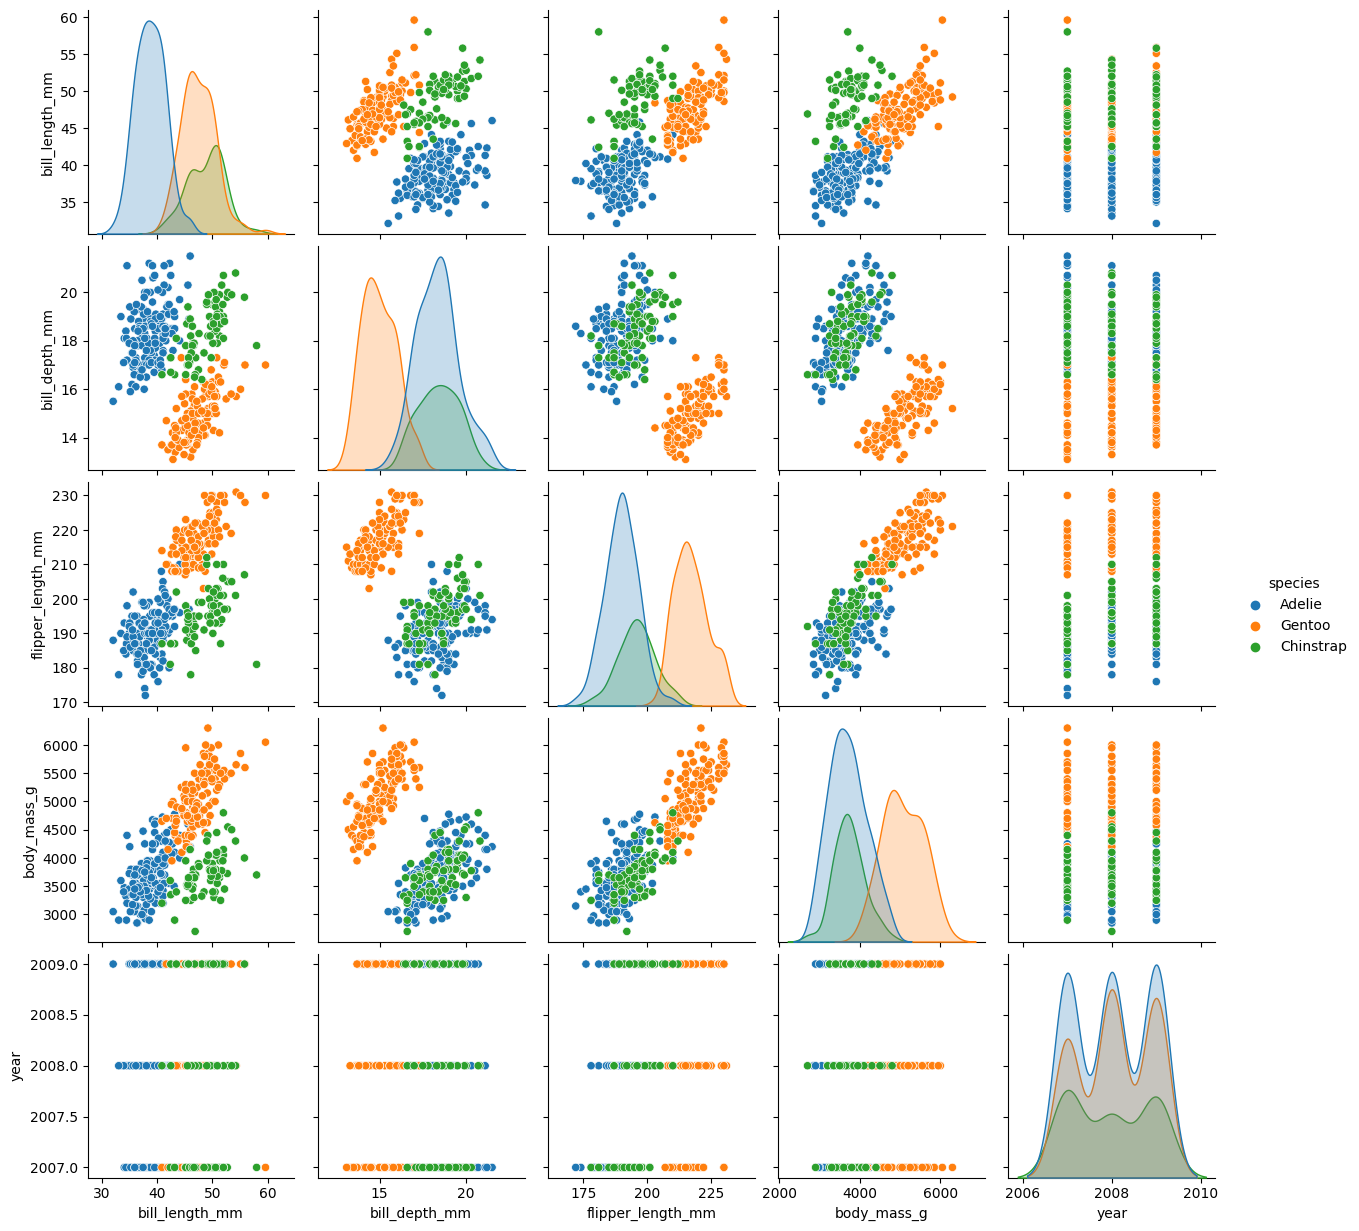

In [ ]:
sns.pairplot(df, hue= "species")

In [ ]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [ ]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [ ]:
target = pd.get_dummies(df['species'])
target.head()

,Adelie,Chinstrap,Gentoo
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


En este subDataSet se ha convertido la clase en una terna, en la cual determina la categoria de acuerdo a la posicion del 1 y los ceros.

In [ ]:
numeric_cols =['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
categorical_cols = ['sex']

for species in df['species'].unique():
    # Filter by species
    species_df = df[df['species'] == species]

    # Replace null values in numeric columns with the median
    for col in numeric_cols:
        species_df[col].fillna(species_df[col].median(), inplace=True)

    # Replace null values in categorical columns with mode
    for col in categorical_cols:
        species_df[col].fillna(species_df[col].mode().iloc[0], inplace=True)

    # Update the original dataframe with the replaced values
    df.update(species_df)

df.head()

<ipython-input-48-c8f7532b4913>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_df[col].fillna(species_df[col].median(), inplace=True)
<ipython-input-48-c8f7532b4913>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_df[col].fillna(species_df[col].median(), inplace=True)
<ipython-input-48-c8f7532b4913>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_df[col].fillna(species_df[col].median(), inplace=True)
<ipy

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007.0
3,Adelie,Torgersen,38.8,18.4,190.0,3700.0,female,2007.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007.0


In [ ]:
features = df.drop(columns = ['species', 'island','sex'])
features

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,39.1,18.7,181.0,3750.0,2007.0
1,39.5,17.4,186.0,3800.0,2007.0
2,40.3,18.0,195.0,3250.0,2007.0
3,38.8,18.4,190.0,3700.0,2007.0
4,36.7,19.3,193.0,3450.0,2007.0
...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,2009.0
340,43.5,18.1,202.0,3400.0,2009.0
341,49.6,18.2,193.0,3775.0,2009.0
342,50.8,19.0,210.0,4100.0,2009.0


Otro subDataSet dejando solo las caracteristicas y quitando la clasificacion de las mismas.

In [ ]:
features = (features - features.min())/ (features.max() - features.min())

In [ ]:
features.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,0.254545,0.666667,0.152542,0.291667,0.0
1,0.269091,0.511905,0.237288,0.305556,0.0
2,0.298182,0.583333,0.389831,0.152778,0.0
3,0.243636,0.630952,0.305085,0.277778,0.0
4,0.167273,0.738095,0.355932,0.208333,0.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, shuffle=True)

##4. Seleccionar el modelo

In [ ]:
from tensorflow import keras

In [ ]:
X_train.shape

(275, 5)

In [ ]:
from numpy import shape
inputs = keras.Input(shape = X_train.shape[1])

In [ ]:
hidden_layer = keras.layers.Dense(10, activation= 'relu')(inputs)

In [ ]:
y_train.shape

(275, 3)

In [ ]:
output_layer = keras.layers.Dense(y_train.shape[1], activation = 'softmax')(hidden_layer)

In [ ]:
model = keras.Model(inputs =inputs, outputs= output_layer)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5)]               0         
                                                                 
 dense (Dense)               (None, 10)                60        
                                                                 
 dense_1 (Dense)             (None, 3)                 33        
                                                                 
Total params: 93
Trainable params: 93
Non-trainable params: 0
_________________________________________________________________


##5. Seleccionar una función de Loss y un optimizador

In [ ]:
model.compile(optimizer = "adam", loss = keras.losses.CategoricalCrossentropy())

##6. Entrenar el modelo

In [ ]:
history = model.fit(X_train, y_train, epochs = 1000)

Epoch 1/1000
9/9 [==============================] - 1s 3ms/step - loss: 1.1345
Epoch 2/1000
9/9 [==============================] - 0s 4ms/step - loss: 1.1183
Epoch 3/1000
9/9 [==============================] - 0s 4ms/step - loss: 1.1041
Epoch 4/1000
9/9 [==============================] - 0s 2ms/step - loss: 1.0917
Epoch 5/1000
9/9 [==============================] - 0s 3ms/step - loss: 1.0788
Epoch 6/1000
9/9 [==============================] - 0s 2ms/step - loss: 1.0665
Epoch 7/1000
9/9 [==============================] - 0s 2ms/step - loss: 1.0552
Epoch 8/1000
9/9 [==============================] - 0s 2ms/step - loss: 1.0443
Epoch 9/1000
9/9 [==============================] - 0s 3ms/step - loss: 1.0347
Epoch 10/1000
9/9 [==============================] - 0s 2ms/step - loss: 1.0248
Epoch 11/1000
9/9 [==============================] - 0s 3ms/step - loss: 1.0146
Epoch 12/1000
9/9 [==============================] - 0s 2ms/step - loss: 1.0055
Epoch 13/1000
9/9 [==============================

<Axes: >

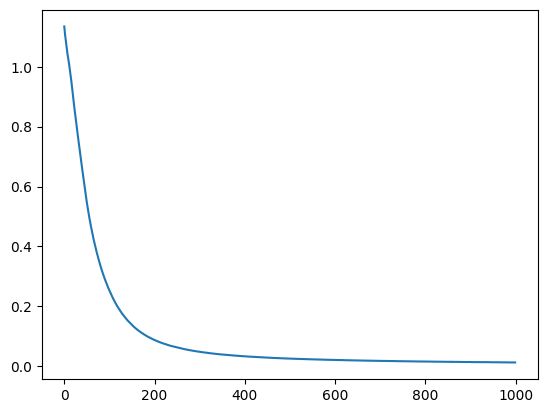

In [ ]:
sns.lineplot(x = history.epoch, y = history.history["loss"])

##7. Realizar una predicción/clasificación

In [ ]:
y_pred = model.predict(X_test)
prediction = pd.DataFrame(y_pred, columns = target.columns)
prediction

3/3 [==============================] - 0s 4ms/step


,Adelie,Chinstrap,Gentoo
0,9.999980e-01,1.858006e-06,2.538462e-08
1,9.973154e-01,2.674584e-03,1.010954e-05
2,4.569681e-06,2.488686e-05,9.999705e-01
3,9.999992e-01,2.393051e-08,7.128293e-07
4,5.231852e-09,3.794621e-06,9.999961e-01
...,...,...,...
64,9.835827e-01,1.641113e-02,6.261199e-06
65,9.999874e-01,1.245247e-05,2.035101e-07
66,9.999776e-01,2.080904e-05,1.518480e-06
67,4.786866e-06,2.000884e-04,9.997951e-01


In [ ]:
predicted_class = prediction.idxmax(axis = "columns")
predicted_class

0        Adelie
1        Adelie
2        Gentoo
3        Adelie
4        Gentoo
        ...    
64       Adelie
65       Adelie
66       Adelie
67       Gentoo
68    Chinstrap
Length: 69, dtype: object

##8. Obtener una medida de rendimiento

In [ ]:
from sklearn.metrics import confusion_matrix

true_class = y_test.idxmax(axis = 'columns')

matrix = confusion_matrix(true_class, predicted_class)
print(matrix)

[[34  0  0]
 [ 0 11  0]
 [ 0  0 24]]


<Axes: xlabel='predited label', ylabel='true label'>

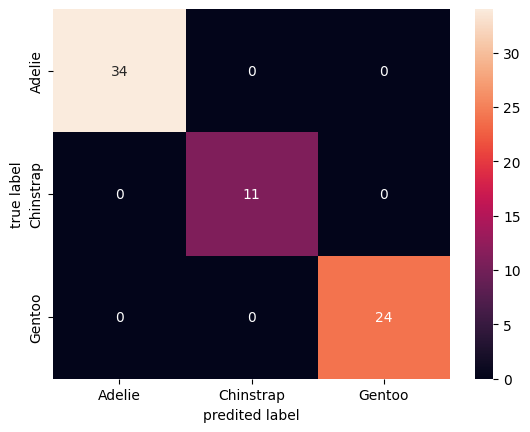

In [ ]:
confusion_df = pd.DataFrame(matrix, index = y_test.columns.values, columns = y_test.columns.values)

confusion_df.index.name = "true label"
confusion_df.columns.name = "predited label"

sns.heatmap(confusion_df, annot = True)

##9. Ajustar los hiperparámetros

##10. Guardar/Recupear el modelo